In [52]:
import math
import time
from typing import List
from pathlib import Path
import os
import sys
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import sobel
from scipy.interpolate import UnivariateSpline


from chars import greek, phys


In [53]:
cwd = Path(os.getcwd())

results_dir = cwd / "WS2_Grating_Eamonn" / "Results" / 'feature testing' / 't=26.0nm Λ=500nm FF=0.76 N=75' / 'data'

files = sorted(os.listdir(results_dir))
file_R = results_dir / files[4]
file_R_sub = results_dir / files[5]
print(file_R)


C:\Users\whamp\PycharmProjects\research_project\WS2_Grating_Eamonn\Results\feature testing\t=26.0nm Λ=500nm FF=0.76 N=75\data\feature testing - t=26.0nm Λ=500nm FF=0.76_R.csv


In [54]:
R = pd.read_csv(file_R, index_col=0)
Rsub = pd.read_csv(file_R_sub, index_col=0)

signalR = (R - Rsub) / Rsub
signalR = (signalR - np.min(signalR)) / (np.max(signalR) - np.min(signalR))

signalR.describe()

,-5.000000000000000000e+00,-4.864864864864864913e+00,-4.729729729729729826e+00,-4.594594594594594739e+00,-4.459459459459459651e+00,-4.324324324324324564e+00,-4.189189189189189477e+00,-4.054054054054054390e+00,-3.918918918918918859e+00,-3.783783783783783772e+00,...,3.783783783783784216e+00,3.918918918918919303e+00,4.054054054054054390e+00,4.189189189189189477e+00,4.324324324324324564e+00,4.459459459459459651e+00,4.594594594594594739e+00,4.729729729729729826e+00,4.864864864864864913e+00,5.000000000000000000e+00
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,...,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,0.283964,0.283668,0.283846,0.283767,0.283377,0.283278,0.283218,0.282631,0.281685,0.280487,...,0.280487,0.281685,0.282631,0.283218,0.283278,0.283377,0.283767,0.283846,0.283668,0.283964
std,0.136601,0.140461,0.143797,0.146890,0.150780,0.155130,0.158850,0.162555,0.166979,0.171309,...,0.171309,0.166979,0.162555,0.158850,0.155130,0.150780,0.146890,0.143797,0.140461,0.136601
min,0.082932,0.055672,0.032436,0.031215,0.038515,0.048617,0.023343,0.015836,0.020207,0.028406,...,0.028406,0.020207,0.015836,0.023343,0.048617,0.038515,0.031215,0.032436,0.055672,0.082932
25%,0.197943,0.198150,0.194122,0.196707,0.185851,0.188040,0.186961,0.187529,0.183603,0.179696,...,0.179696,0.183603,0.187529,0.186961,0.188040,0.185851,0.196707,0.194122,0.198150,0.197943
50%,0.264478,0.265977,0.263851,0.267793,0.268046,0.269938,0.275851,0.268093,0.269371,0.256269,...,0.256269,0.269371,0.268093,0.275851,0.269938,0.268046,0.267793,0.263851,0.265977,0.264478
75%,0.336088,0.331369,0.327540,0.327380,0.327290,0.329002,0.325969,0.322622,0.310127,0.300639,...,0.300639,0.310127,0.322622,0.325969,0.329002,0.327290,0.327380,0.327540,0.331369,0.336088
max,0.852865,0.869799,0.885535,0.900054,0.913356,0.925453,0.936371,0.946149,0.954833,0.962480,...,0.962480,0.954833,0.946149,0.936371,0.925453,0.913356,0.900054,0.885535,0.869799,0.852865


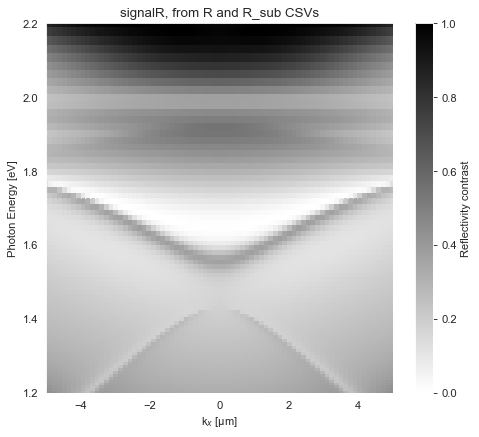

In [55]:
N=75
lbda_min = 1240 / 2.2 # y limits
lbda_max = 1240 / 1.2
lbda = np.linspace(lbda_min/1000,lbda_max/1000,N)
N_k=N
# k_scan=np.linspace(-6.7,6.7,N_k) #mu-1
kmax=5
k_scan=np.linspace(-kmax,kmax,N_k) #mu-1
ky=0.000
title_name = 'signalR, from R and R_sub CSVs'

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,1.240/lbda,signalR,cmap='binary',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title=title_name)
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()

(75, 75)


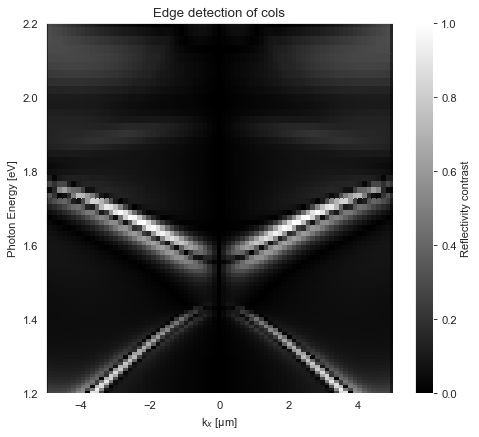

In [56]:
cwd=Path(os.getcwd())
testpath = cwd / 'test'
testpath.mkdir(exist_ok=True, parents=True)


data_array = np.asarray(signalR)
sobel_y = sobel(data_array, axis=1) # Apply the Sobel operator y direction

edge_magnitude = np.abs(sobel_y)

# Normalize edge magnitude for better visualization
edge_magnitude_normalized = edge_magnitude / np.max(edge_magnitude)

print(edge_magnitude.shape)

fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,1.240/lbda,edge_magnitude_normalized,cmap='gray',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title='Edge detection of cols')
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
plt.minorticks_on()
plt.savefig(testpath / 'edgedetect.png', dpi=150)


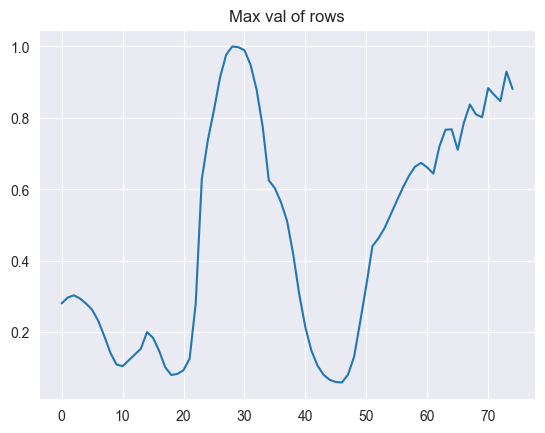

In [57]:

from scipy.signal import find_peaks

# find the coords of above and below the top mode, identify the gap
line_y_max = [np.max(row) for row in edge_magnitude_normalized]

pd_line_y_max = pd.Series(line_y_max)
pd_line_y_max.plot(title='Max val of rows')

plt.savefig(testpath / 'lineprofile.png', dpi=150)


Peak at 14 - before=10, after=18, diff 0.09538382463597786
Peak at 28 - before=18, after=46, diff 0.9194130405295452
Peak at 59 - before=46, after=61, diff 0.03003789199402873
Peak at 64 - before=61, after=65, diff 0.057256049459742386
Peak at 67 - before=65, after=69, diff 0.035571246543684154
Peak at 70 - before=69, after=72, diff 0.03643754037365232
Found peak at idx 28


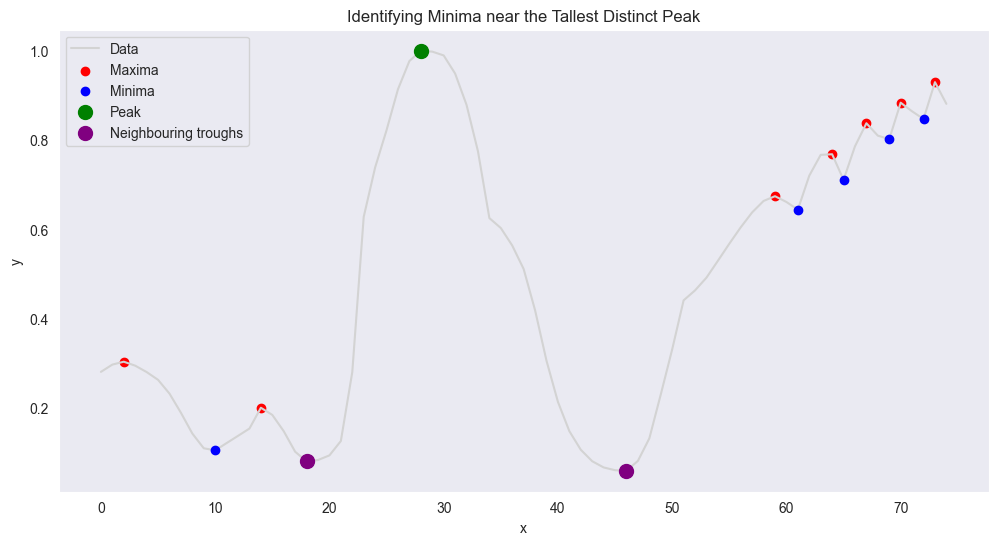

In [58]:

# Use the Series index as x values
y = pd_line_y_max
x = pd_line_y_max.index

peaks, _ = find_peaks(y)
troughs, _ = find_peaks(-y)  # Invert y to find minima

# peaks_df = pd.Series(peaks)
# troughs_df = pd.Series(troughs)
# pt_df = pd.DataFrame({'peaks':peaks_df, 'troughs':troughs_df})
# print(pt_df)

minima_indices = troughs
min_peak_trough_diff = 0.6

max_peak = None # [loc, comparable diff]
min_troughs = None # [loc1, loc2]

for _,peak in enumerate(peaks):
    before_trough = troughs[troughs < peak].max() if (troughs < peak).any() else None
    after_trough = troughs[troughs > peak].min() if (troughs > peak).any() else None
    
    if None in [before_trough, after_trough]:
        continue
    before_trough = int(before_trough)
    after_trough = int(after_trough)
    
    diff1, diff2 = y[peak] - y[before_trough], y[peak] - y[after_trough]
    diff_min = np.min([diff1, diff2]) # find min proximity in y to trough
    
    if max_peak == None or max_peak[1] < diff_min:
        max_peak = [peak,diff_min]
        min_troughs = [before_trough, after_trough]
    
    print(f"Peak at {peak} - before={before_trough}, after={after_trough}, diff {diff_min}")

print(f"Found peak at idx {max_peak[0]}")
    


# Step 5: Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x, y, label='Data', color='lightgray')
plt.scatter(x[peaks], y[peaks], color='red', label='Maxima')
plt.scatter(x[minima_indices], y[minima_indices], color='blue', label='Minima', zorder=5)
plt.scatter(x[max_peak[0]], y[max_peak[0]], color='green', label='Peak', s=100, zorder=10)
plt.scatter([x[min_troughs[0]], x[min_troughs[1]]], [y[min_troughs[0]], y[min_troughs[1]]], color='purple', label='Neighbouring troughs', s=100, zorder=10)
plt.title('Identifying Minima near the Tallest Distinct Peak')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

plt.savefig(testpath / 'peaks.png', dpi=150)
plt.show()

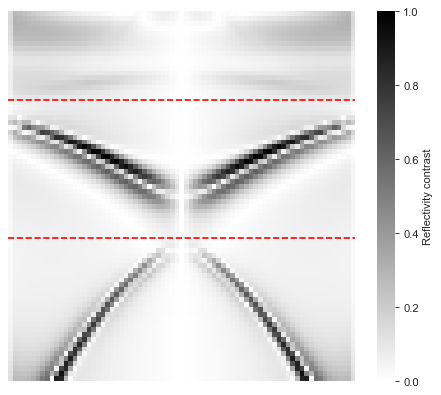

In [59]:
# Create a new figure for the heatmap
plt.figure(figsize=(7, 6), dpi=80)

# Use seaborn to create a heatmap
sns.heatmap(edge_magnitude_normalized, cmap='binary', cbar_kws={'label': 'Reflectivity contrast'}, 
            xticklabels=False, yticklabels=False)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

plt.minorticks_on()

K_x inflection at -1.9565217391304346, 1.9899665551839467


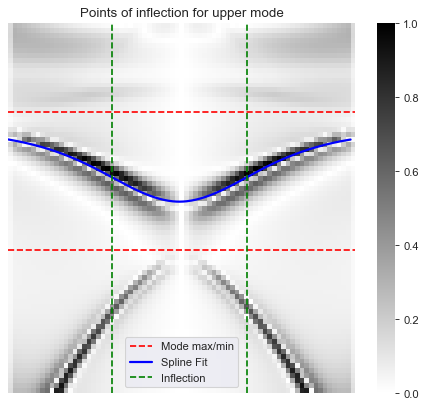

In [60]:
# Sample data generation (replace with your actual data)
# edge_magnitude_normalized = np.random.rand(100, 50)  # Example heatmap data
# min_troughs = [20, 80]  # Example trough indices

# Create a new figure for the heatmap
plt.figure(figsize=(7, 6), dpi=80)

# Create the heatmap
sns.heatmap(edge_magnitude_normalized, cmap='binary',
            xticklabels=False, yticklabels=False)

# Add horizontal lines at the minimum troughs
plt.axhline(y=min_troughs[0], color='r', linestyle='--', label='Mode max/min')
plt.axhline(y=min_troughs[1], color='r', linestyle='--')

# Extract the region of interest between the minimum troughs
y_min = min_troughs[0]
y_max = min_troughs[1]

# Extract data between the specified rows
data_region = edge_magnitude_normalized[y_min:y_max, :]  # Get data between min_troughs

# Define a threshold for high values; you can adjust this value as necessary
# Extract the x-coordinates
x_indices = np.arange(data_region.shape[1])  # x-coordinates (columns)

# Calculate the weighted average of y-positions for each x
y_positions = []

for x in x_indices:
    column = data_region[:, x]
    
    # Calculate the 75th percentile (for top 25% of values)
    threshold = np.percentile(column, 85)
    
    # Consider only values above the 75th percentile
    top_quarter = column[column >= threshold]
    y_indices = np.where(column >= threshold)[0]
    
    if len(top_quarter) > 0:
        # Calculate weighted average for the top quarter
        weighted_avg = np.sum(top_quarter * y_indices) / np.sum(top_quarter)
        y_positions.append(weighted_avg + y_min)  # Shift by y_min
    else:
        # If no values above threshold, use the maximum value's position
        y_positions.append(np.argmax(column) + y_min)

# Fit a spline to the weighted average positions
spline_fit = UnivariateSpline(x_indices, y_positions, s=10)  # s=0.5 for some smoothing
x_smooth = np.linspace(0, data_region.shape[1] - 1, 300)
y_smooth = spline_fit(x_smooth)

spline_derivative = spline_fit.derivative()
gradient = spline_derivative(x_smooth)

# plt.plot(x_smooth, gradient, color='green', linewidth=2, label='Gradient')

lhs_inflection = x_smooth[np.argmax(gradient)]
rhs_inflection = x_smooth[np.argmin(gradient)]
# print(f"Gradient: {lhs_inflection}, {rhs_inflection}")

kmax = 5

krange = 2*kmax
scale = krange/np.max(x_smooth)
k_lhs, k_rhs= scale*lhs_inflection-kmax, scale*rhs_inflection-kmax
print(f"K_x inflection at {k_lhs}, {k_rhs}")

plt.plot(x_smooth, y_smooth, color='blue', linewidth=2, label='Spline Fit')

# Add horizontal lines at the minimum troughs
plt.axvline(x=lhs_inflection, color='g', linestyle='--', label='Inflection')
plt.axvline(x=rhs_inflection, color='g', linestyle='--')




# Adding a legend and displaying the plot
plt.legend()
plt.xticks()
plt.minorticks_on()
plt.title('Points of inflection for upper mode')

plt.savefig(testpath / 'inflections.png', dpi=150)
plt.show()


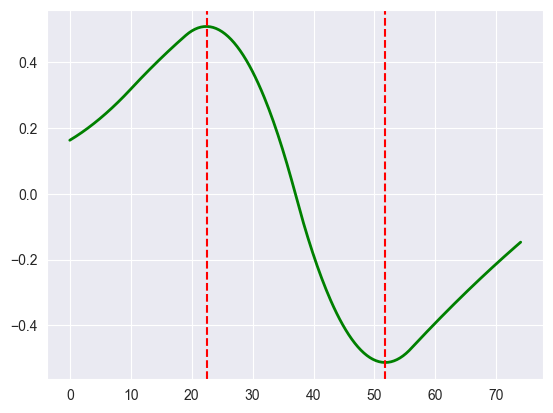

In [61]:
spline_derivative = spline_fit.derivative()
gradient = spline_derivative(x_smooth)

plt.plot(x_smooth, gradient, color='green', linewidth=2, label='Gradient')

# Add horizontal lines at the minimum troughs
plt.axvline(x=lhs_inflection, color='r', linestyle='--')
plt.axvline(x=rhs_inflection, color='r', linestyle='--')


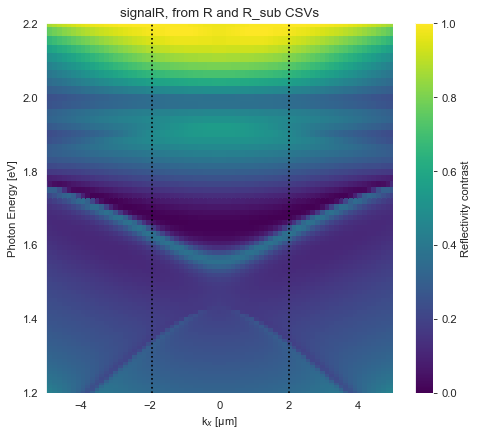

In [62]:
fig, axs = plt.subplots(1, 1, sharey=True, figsize=(7, 6), dpi=80)
pcm = axs.pcolor(k_scan,1.240/lbda,signalR,cmap='viridis',clim=(0,1))
axs.set(xlabel=f'k$_x$ [{greek.mu}m]',xlim=(-kmax,kmax),ylim=(1240/lbda_max, 1240/lbda_min), ylabel='Photon Energy [eV]',title=title_name)
# y_eV = 1.45    # reference line at 1.45eV
# axs.plot(k_scan,y_eV*k_scan/k_scan,'m--') # reference line at 1.45eV
cbar =fig.colorbar(pcm,location='right')
cbar.set_label('Reflectivity contrast')
# plt.minorticks_on()

plt.axvline(x=k_lhs, color='black', linestyle=':', label='Inflection')
plt.axvline(x=k_rhs, color='black', linestyle=':')

plt.xticks()

final = testpath / 'final.png'
plt.savefig(final, dpi=150)